### report of energy comparing for ml and ref J. Chem. Phys. 144, 234312 (2016) SI structures

In [1]:
import pandas as pd
from lzn.universal import *

# Content
- [Processing](#Processing)
- [compare energies](#Compare\denergies)

# Processing
copy and reformat mpa_tio2_10_cluster/energy_summary.csv to tio2_all_out/mpa/energies.csv

In [2]:
gpath = to_path("~/TiO2")
path_ = gpath / "zmpa_tio2_10_cluster/energy_summary.csv"
df = pd.read_csv(path_)

In [3]:
df = df.rename(columns={"file, E/eV": "file"})
df = df.rename(columns={"E_first": "E_initial"})
df = df.rename(columns={"E_last": "E_final"})
df = df.rename(columns={"dE_last_minus_first": "dE"})

In [4]:
del df["E_first_ref"]
del df["E_last_ref"]

In [5]:
df["file"] = df["file"].astype("string").str.removesuffix(".log")
df

,file,E_initial,E_final,dE
0,01_Our_ground_state_see_Section_1_above.xyz,-257.879822,-258.077484,-0.197662
1,02_Ground_state_from_Bhattacharya_et_al_31.xyz,-257.645996,-257.824066,-0.178070
2,03_GS_obtained_by_Shevlin_et_al_22.xyz,-257.470123,-257.664001,-0.193878
3,04_Structure_from_Zhen-Wang_et_al_19_20.xyz,-257.305389,-257.624054,-0.318665
4,05_The_GS_from_Marom_et_al_29.xyz,-257.445496,-257.628021,-0.182525
5,06_Tetrahedral_with_disorder_variation_of_our_...,-256.740265,-256.926453,-0.186188
6,07_Triangular_prism_with_single_mono-coordinat...,-257.126801,-257.312469,-0.185668
7,08_Double_staircase_almost_symmetric.xyz,-256.576416,-256.780334,-0.203918
8,09_Amorphous_square-pentagon-tetrahedral.xyz,-256.381470,-256.599243,-0.217773
9,10_Variation_of_the_triangular_prism.xyz,-255.526520,-256.854340,-1.327820


In [6]:
path_ = gpath / "tio2_Granja_out/mpa/energies.csv"
df.to_csv(path_, index=False)

# Compare energies

In [6]:


refE_path = gpath / "tio2_Granja_xyz/ref_energies.csv"
mlE_dir = gpath / "tio2_Granja_out"

modals = [x for x in mlE_dir.iterdir() if x.is_dir()]
mlE_path = [x / "energies.csv" for x in modals]

print(modals)
print(mlE_path)

df_ml = [pd.read_csv(x) for x in mlE_path]
df_ml = [x["E_initial"] for x in df_ml]

[PosixPath('/home/zining/TiO2/tio2_Granja_out/matpes_pbe'), PosixPath('/home/zining/TiO2/tio2_Granja_out/omol25_low'), PosixPath('/home/zining/TiO2/tio2_Granja_out/mpa'), PosixPath('/home/zining/TiO2/tio2_Granja_out/matpes_r2scan')]
[PosixPath('/home/zining/TiO2/tio2_Granja_out/matpes_pbe/energies.csv'), PosixPath('/home/zining/TiO2/tio2_Granja_out/omol25_low/energies.csv'), PosixPath('/home/zining/TiO2/tio2_Granja_out/mpa/energies.csv'), PosixPath('/home/zining/TiO2/tio2_Granja_out/matpes_r2scan/energies.csv')]


In [7]:
for x in df_ml:
    ref_energy = x[0]
    x[:] = x[:] - ref_energy
    print(ref_energy)


-257.1328125
-272142.5
-257.879822
-333.25439453125


load reference energy

In [10]:
path_ = gpath / "tio2_Granja_xyz/ref_energies.csv"

df_ref = pd.read_csv(path_)
del df_ref["energy"]

combine all

In [11]:
col_names = [str(x.name) for x in modals]
print(col_names)
df_all = pd.concat(df_ml, axis=1)
df_all.columns = col_names

['matpes_pbe', 'omol25_low', 'mpa', 'matpes_r2scan']


In [12]:
df_all = pd.concat([df_ref, df_all], axis=1)

In [64]:
path_ = to_path("~/organized/901_data/granja_all40.csv")
df_all.to_csv(path_)
df_all

,file_name,ref_energy,matpes_pbe,omol25_low,mpa,matpes_r2scan
0,"Our ground state, see Section 1 above",0.000000,0.000000,0.00000,0.000000,0.000000
1,Ground state from Bhattacharya et al [31],1.157932,-0.026733,0.93750,0.233826,0.487549
2,GS obtained by Shevlin et al [22],1.189535,0.511536,0.59375,0.409699,0.468109
3,"Structure from Zhen-Wang et al [19, 20]",1.219688,0.639496,0.81250,0.574433,0.661224
4,"The GS from Marom et al [29],",1.488757,0.159729,1.31250,0.434326,0.766479
5,Tetrahedral with disorder variation of our GS,1.510045,1.098969,1.31250,1.139557,1.327972
6,Triangular prism with single mono-coordinated ...,1.758129,0.696869,1.65625,0.753021,1.182556
7,Double staircase almost symmetric,2.219716,1.259216,1.90625,1.303406,1.641113
8,Amorphous square-pentagon-tetrahedral,2.965696,1.204315,2.75000,1.498352,2.041565
9,Variation of the triangular prism,2.971557,2.314606,3.21875,2.353302,2.891510


In [25]:
import matplotlib.pyplot as plt
from plot_with_regression import plot_with_regression

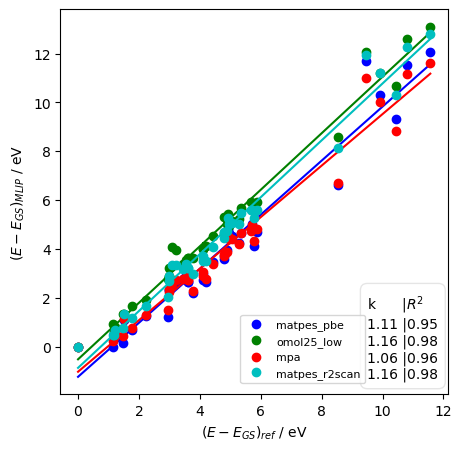

In [63]:
num = 40 # plot first num modals

fig1 = plt.figure(1, figsize = (5,5))
gs = fig1.add_gridspec(1,1)
grid_n = fig1.add_subplot(gs[0,0])

x = df_all.loc[:]["ref_energy"]
ycols = df_all.columns[2:6]             # number of columns (modals)

slope_l, se_l = [], []
for j, col_ in enumerate(ycols):
    grid_n, slope, se = plot_with_regression(grid_n, j, x, df_all[col_][:num].to_numpy(), col_)
    slope_l.append(slope)
    se_l.append(se)

lreg_text = "\n".join([r"k      |$R^2$"] + [f"{slope_l[i_]:.2f} |{se_l[i_]:.2f}" for i_ in range(4)])

grid_n.set_ylabel(r"$(E-E_{GS})_{MLIP}$ / eV")
grid_n.set_xlabel(r"$(E-E_{GS})_{ref}$ / eV")
grid_n.legend(fontsize=8, loc="upper left", bbox_to_anchor=(0.45, 0.22))  # outside right
grid_n.text(
    9.5, -1.3 ,
    lreg_text,
    fontsize=10,
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.2, edgecolor='gray')
    )

fig.tight_layout()

path_ = to_path("~/organized/901_data/granja_all40.pdf")
fig1.savefig(path_)

plt.show()
